### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

/var/folders/gv/jtdbv_2n0sl_9c1c0kbw4rp80000gn/T/ipykernel_71192/1290318131.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


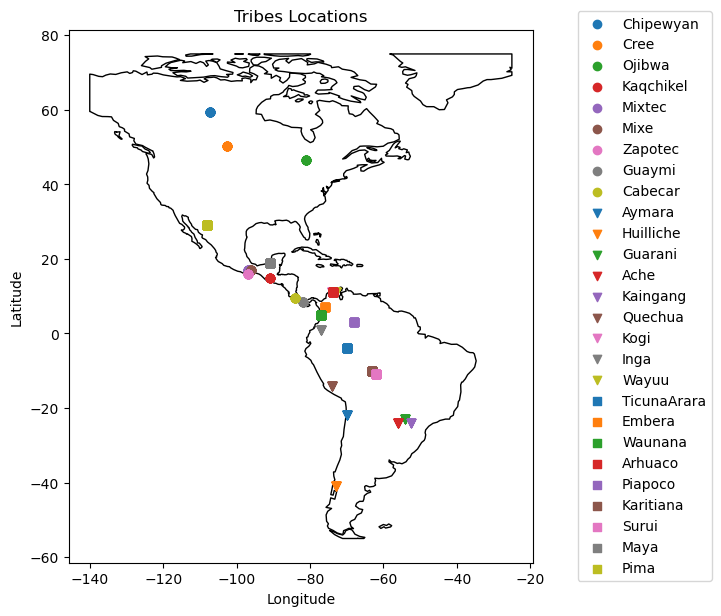

In [1]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')  #loads the data from the txt file, values are seperated by space

# Extract relevant columns
latitude = df.iloc[:, 6]       #saves the latitude, longitude and tribe values as variables
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude)) #creates a geo df from our original df

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black') #bounds the map [min long, min lat, max long, max lat]
marker_list = ['o', 'v', 's'] #list of three types of markers
colors_list = [f'C{i}' for i in range(9)] #create a list of 9 colors
for i, tribe in enumerate(gdf['Pop'].unique()): #loop over the unique tribe names
    members_tribe = gdf[gdf['Pop'] == tribe] #df filtered on the current tribe
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe) # plots a marker for the tribe with marker type and color decided by the order of which we loop over the tribes, adds tribe label
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')  #loads the data from the txt file, values are seperated by space

# Extract relevant columns
latitude = df.iloc[:, 6]       #saves the latitude, longitude and tribe values as variables
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]


In [3]:
import sys
print(sys.executable)

/Users/petreanorgren/anaconda3/bin/python


## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

### Answer:

Yes. I ran into the error: `LinAlgError: Singular matrix`. Since we have many more predictors (5710) vs number of observations (494). Many columns in X will be linearly dependent and hence $X^TX$ will not be of full rank and therefore not invertible aka. $X^TX$ will be a singular matrix. 

In [4]:
import numpy as np

y = df['long'].values
X = df[df.columns[8:]].copy()
X['intercept'] = np.ones_like(y)
X = X.values

print(X.shape)
print(y.shape)
print((X.T @ X).shape)
inv = np.linalg.solve(X.T @ X, np.eye(X.shape[1]))
beta_hat = inv @ X.T @ y 

print(beta_hat)


(494, 5710)
(494,)
(5710, 5710)


LinAlgError: Singular matrix

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.


### Answer:

No, this time we did not run into any errors. The error from before occured because `numpy.linalg.solve` looks for the exact solution to: min $||X \beta - y||$ which only exsits for matrices of full rank. In our case we have multiple solutions to: min $ ||X \beta - y||$ and hence we receive an error for `numpy.linalg.solve`. `numpy.linalg.lstsq` instead looks for the best solution if there are multiple, i.e the one with the least L2-norm and hence offers a solution to the case with several solutions. 




In [7]:
beta_hat = np.linalg.lstsq(X.T @ X, X.T @ y, rcond=None)[0]
print(beta_hat)


[-0.04005413 -0.01943802  0.01111183 ... -0.10203467  0.01814151
 -0.47674258]


 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 


### Answer c):
No they are not the same. The re-centering of the predictors before training ensures that the mean of the training dataset is 0. This is practical in cases where the mean of one or more predictors differs greatly from 0. Re-centering the dataset makes it easier to differentiate between datapoints on opposite sides of the mean even though the datapoints are close. This is why the intercept is different in the two approaches.

In [8]:
from sklearn.linear_model import LinearRegression

# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression lr
lr = LinearRegression()
lr.fit(X, y)

sk_beta_hat = np.zeros_like(beta_hat)
sk_beta_hat[0:-1] = lr.coef_
sk_beta_hat[-1] = lr.intercept_
diff = abs(sk_beta_hat-beta_hat)
e = 1*10**(-2)
more_than_e = (diff > e).sum()*100/len(beta_hat)
print('Amount of paramters with an absolute difference above ', e, ':', round(more_than_e,0), '%')

print('beta_hat from b) : ',beta_hat[0:5])
print('beta_hat from sk_learn', sk_beta_hat[0:5])
print('intercept b) :', beta_hat[-1])
print('intercept sk_learn :', sk_beta_hat[-1])


Amount of paramters with an absolute difference above  0.01 : 74.0 %
beta_hat from b) :  [-0.04005413 -0.01943802  0.01111183 -0.01221626 -0.02461028]
beta_hat from sk_learn [-0.03940988 -0.0245272   0.01089763  0.01066482 -0.02470103]
intercept b) : -0.4767425758992693
intercept sk_learn : -84.01040409306009


## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.


Pricipal Component Analysis is a form of dimesion reduction that dissects the dataset into a set of vectors (Principal Components) that will contain maximum amount of variance. 

Geometrical Intrepretation:
The dimensionality reduction is performed by projecting the dataset onto its eigenvectors corresponding to the eigenvalues of maximum value (SPSD).


Statistical Interpretation:
Pricipal Components are calculated by selecting the direction that captures maximum variance of the data, the next PC will be orthogonal to previous PC:s and will contain maximum amount of remaining variance etc.

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

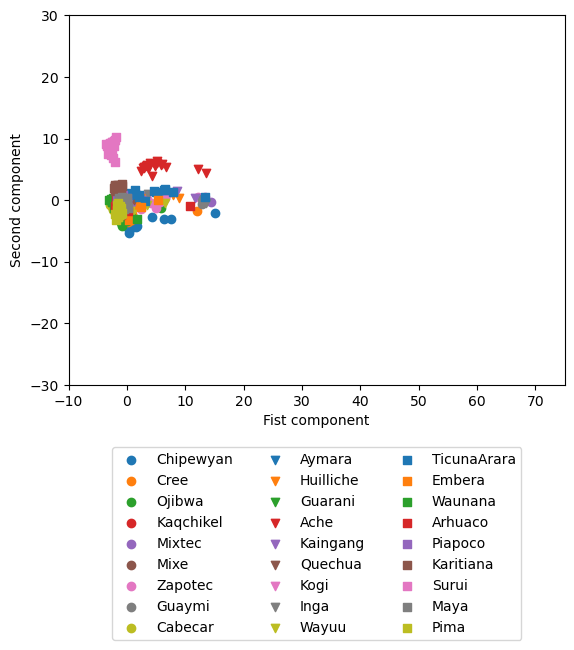

In [11]:
from sklearn.decomposition import PCA

X = df[df.columns[8:]].values
pca = PCA()
components = pca.fit_transform(X)



scatter_df = pd.DataFrame()
scatter_df['x'] = components[:,0]
scatter_df['y'] = components[:, 1]
scatter_df['tribe'] = df['Pop'].values
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    to_plot = scatter_df[scatter_df['tribe'] == tribe]
    plt.scatter(to_plot['x'],to_plot['y'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)

plt.xlabel('Fist component')
plt.ylabel('Second component')
plt.ylim(-30,30)
plt.xlim(-10,75)
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3
)
plt.show()


**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

## Answer:

We can see that the data points becomes more spread out.

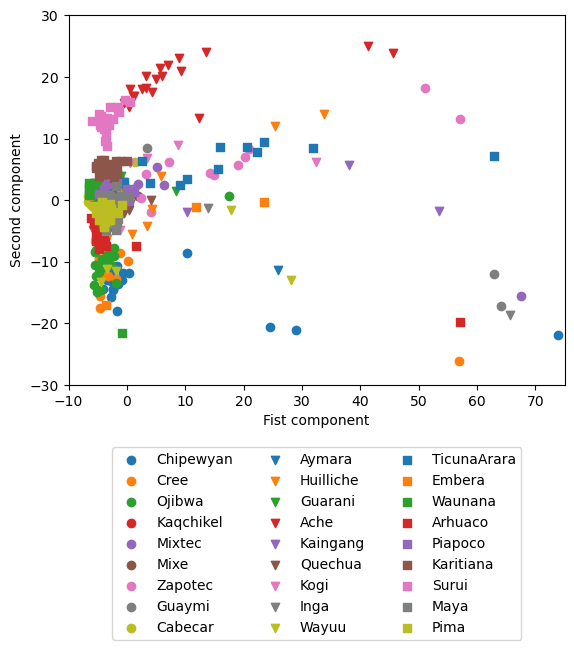

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)

pca_std = PCA()
components_std = pca_std.fit_transform(X_std)

scatter_df['x_std'] = components_std[:,0]
scatter_df['y_std'] = components_std[:,1]

for i, tribe in enumerate(gdf['Pop'].unique()):
    to_plot = scatter_df[scatter_df['tribe'] == tribe]
    plt.scatter(to_plot['x_std'],to_plot['y_std'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
plt.xlabel('Fist component')
plt.ylabel('Second component')
plt.ylim(-30,30)
plt.xlim(-10,75)
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3
)
plt.show()

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

### Answer
Standardizing the datapoints is essential in the context of PCA in order to correctly represent the variance of all feature in a fair and representative way. If this is ignored the variance will be weigthed differently based on the magnitude of each feature.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

### Answer

Precentege of variance captured by the first two components is approximatly 3,4 %. With 298 components we would be able to capture about 80% of the variance. 

Precentage captured by first component:  2.3674931488329576
Precentage captured by the second component:  1.0254201715358329
Total:  3.3929133203687907


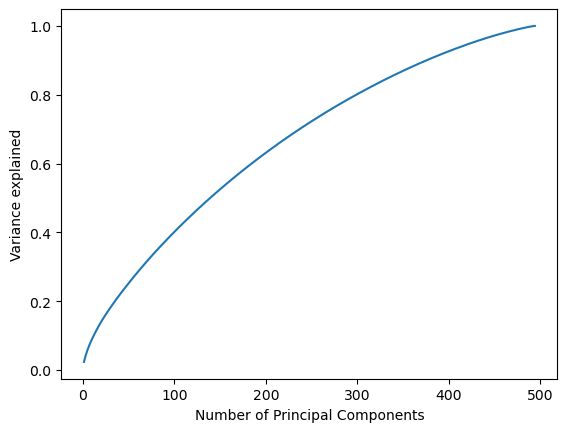

298


In [13]:
variances = pca_std.explained_variance_ratio_
cumulative_variances = np.cumsum(variances)

print("Precentage captured by first component: ", variances[0]*100)
print("Precentage captured by the second component: ", variances[1]*100)
print("Total: ", cumulative_variances[1]*100)
x = np.arange(1, len(variances)+1)
plt.plot(x, cumulative_variances) 
plt.ylabel("Variance explained")
plt.xlabel("Number of Principal Components")
plt.show()

print(np.argmax(cumulative_variances >= 0.8))

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

## Answer

The predicted map shows the tribes as many scattered points vs the one made in Exercise 1, where each tribe is a singular point because all members share the same coordinates. It looks like the points are generally geographically correct with the predicted points roughly centered about the true location. 

The map is probably too optimistic as the model was trained and tested on the same set, thus leading to overfitting and a much smaller error than what would be realistic given new samples outside the database.

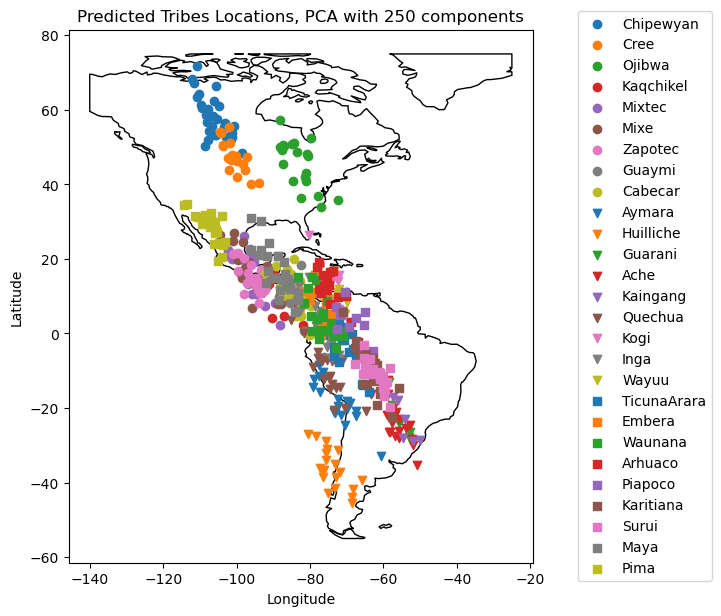

In [14]:
y_lat = df['lat'].values
y_long = df['long'].values

pca = PCA(n_components=250)
X_pca = pca.fit_transform(X) 

lr_lat  = LinearRegression().fit(X_pca, y_lat)
lr_long = LinearRegression().fit(X_pca, y_long)
lat_pred = lr_lat.predict(X_pca)
long_pred = lr_long.predict(X_pca)


world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black') #bounds the map [min long, min lat, max long, max lat]
marker_list = ['o', 'v', 's'] #list of three types of markers
colors_list = [f'C{i}' for i in range(9)] #create a list of 9 colors
for i, tribe in enumerate(gdf['Pop'].unique()): #loop over the unique tribe names
    mask = df['Pop'] == tribe #boolean mask for the current tribe
    ax.scatter(long_pred[mask], lat_pred[mask], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe) # plots a marker for the tribe with marker type and color decided by the order of which we loop over the tribes, adds tribe label
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Predicted Tribes Locations, PCA with 250 components')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()


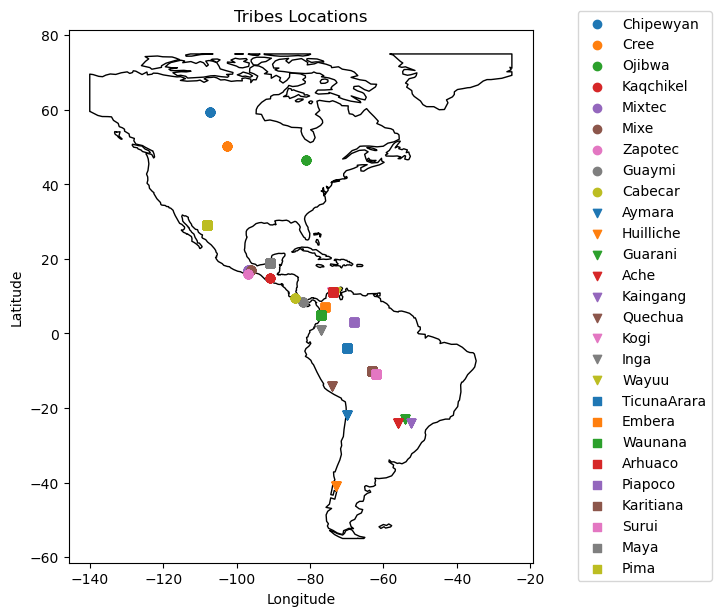

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [15]:
from sklearn.metrics.pairwise import haversine_distances

real_coords = np.deg2rad(np.column_stack([y_lat,   y_long]))
pred_coords = np.deg2rad(np.column_stack([lat_pred, long_pred]))
dist_matrix   = haversine_distances(real_coords, pred_coords)   # N × N
distances_rad = np.diag(dist_matrix)                            # N distances (radians)

# Convert radians to kilometers (Earth's radius in kilometers)
R_earth = 6371.0
distances_km = distances_rad * R_earth

mean_error_km = np.mean(distances_km)
print(f"Mean distance between real and predicted coordinates: {mean_error_km:.2f} km")

Mean distance between real and predicted coordinates: 634.05 km


## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

## Answer

Cross-validation is a method to evaluate a models perfomance in order to tune hyperparameters and simuontaniously ensuring that the model generlizes well to useen data. A common approach is k-fold cross-validation where the training data is split into k different subsets, training the model on k-1 subsets and validating it on the remaining subset, rotating which subset is used for validation ensuring that the model generalizes well to new data. In the end averaging the errors to give a more accurate error estimate. If this process is repreated with different splits we get a new CV-method called repeated K-fold Cross Validation. 

A third CV-method is Stratified K-Fold validation which is useful when we cannot assume that splitting the dataset into K equally sized folds will yield a representative sampled distribution of the complete dataset. This occurs when the dataset is imbalanced. Stratisfied K-fold works by ensuring that every fold is representative of the entire dataset (so that every fold contains the same ratio of every class). 

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

## Answer
Since every person belonging to the same tribe all share the same latitude and longitude an appropriate CV-method would be Group-K-Fold, this ensures that the same tribe is not represented in both test- and training set


**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [16]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer


def mean_dist_error(pred_coords, real_coords):
    R_earth = 6371.0
    real_coords = np.deg2rad(real_coords)
    pred_coords = np.deg2rad(pred_coords)
    dist_matrix   = haversine_distances(real_coords, pred_coords)   # N × N
    distances_rad = np.diag(dist_matrix)                            # N distances (radians)
    distances_km = distances_rad * R_earth
    mean_error_km = np.mean(distances_km)
    return mean_error_km

scorer = make_scorer(mean_dist_error, greater_is_better=True) #Not acutually true but dont wnat sign flip...

pipe = make_pipeline(
    StandardScaler(),
    PCA(n_components=4),
    LinearRegression()
)

cv = GroupKFold(n_splits=10)

y = df[['lat', 'long']].values

score = cross_validate(pipe, X, y, groups=df['Pop'].values, cv=cv, scoring=scorer, return_train_score=True)

print('Mean train score across splits:', score['train_score'].mean())
print('Mean test score across splits:', score['test_score'].mean())



Mean train score across splits: 1916.5558835795684
Mean test score across splits: 2445.6546138168155


**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

2
12
22
32
42
52
62
72
82
92
102
112
122
132
142
152
162
172
182
192
202
212
222
232
242
252
262
272
282
292
302
312
322
332
342
352
362
372
382
392
402
412
422
432


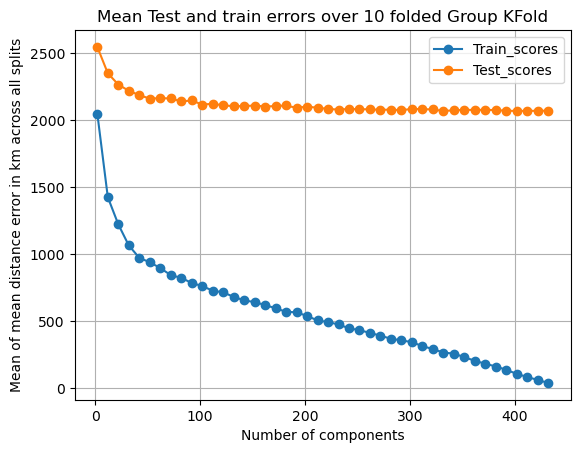

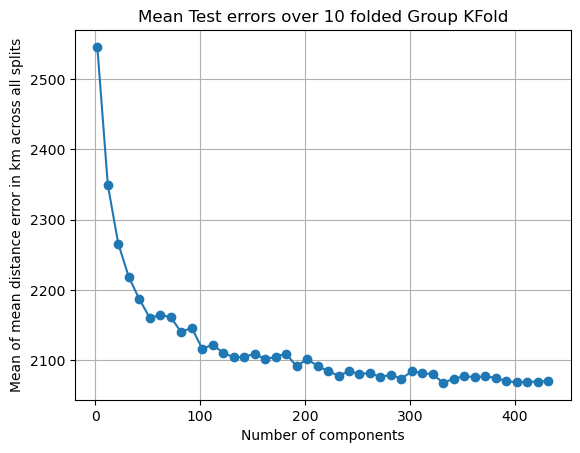

In [17]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer


def mean_dist_error(pred_coords, real_coords):
    R_earth = 6371.0
    real_coords = np.deg2rad(real_coords)
    pred_coords = np.deg2rad(pred_coords)
    dist_matrix   = haversine_distances(real_coords, pred_coords)   # N × N
    distances_rad = np.diag(dist_matrix)                            # N distances (radians)
    distances_km = distances_rad * R_earth
    mean_error_km = np.mean(distances_km)
    return mean_error_km

scorer = make_scorer(mean_dist_error, greater_is_better=True) #Not acutually true but dont wnat sign flip...

y = df[['lat', 'long']].values
cv = GroupKFold(n_splits=10)

train_scores = []
test_scores = []
num_c = []
for n_components in range(2,440,10):
    print(n_components)
    pipe = make_pipeline(
        StandardScaler(),
        PCA(n_components=n_components),
        LinearRegression()
    )
    score = cross_validate(pipe, X, y, groups=tribes, cv=cv, scoring=scorer, return_train_score=True)
    train_scores.append(score['train_score'].mean())
    test_scores.append(score['test_score'].mean())
    num_c.append(n_components)

plt.plot(num_c, train_scores, label='Train_scores', marker='o')
plt.plot(num_c, test_scores, label='Test_scores', marker='o')
plt.legend()
plt.grid()
plt.xlabel('Number of components')
plt.ylabel('Mean of mean distance error in km across all splits')
plt.title('Mean Test and train errors over 10 folded Group KFold')
plt.show()

plt.plot(num_c, test_scores, label='Test_scores', marker='o')
plt.xlabel('Number of components')
plt.ylabel('Mean of mean distance error in km across all splits')
plt.title('Mean Test errors over 10 folded Group KFold')
plt.grid()
plt.show()




**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

### Answer
We would keep the model that uses 112 components as we belive it is a good trade off between complexity and accuracy. Looking at the train vs. test error curves above from the cross validation we can see that the test error curve flattens out at around this number of components. The prediction error of the model is: 779 km and the training error is: 735 km. By plotting the predicted locations using `cross_val_predict` where each prediction is made by a model fitted on a training set not containing the tribe to be predicted we can conclude that the model does not preform very well when trying to predict the locations of yet unseen tribes based on genetic markers. 

Number of components:  102
Mean cv train error:  763.5062376560162
Mean cv test error:  2116.089030933245
Mean cv train error:  763.5062376560162
Prediction error:  789.3095550304538


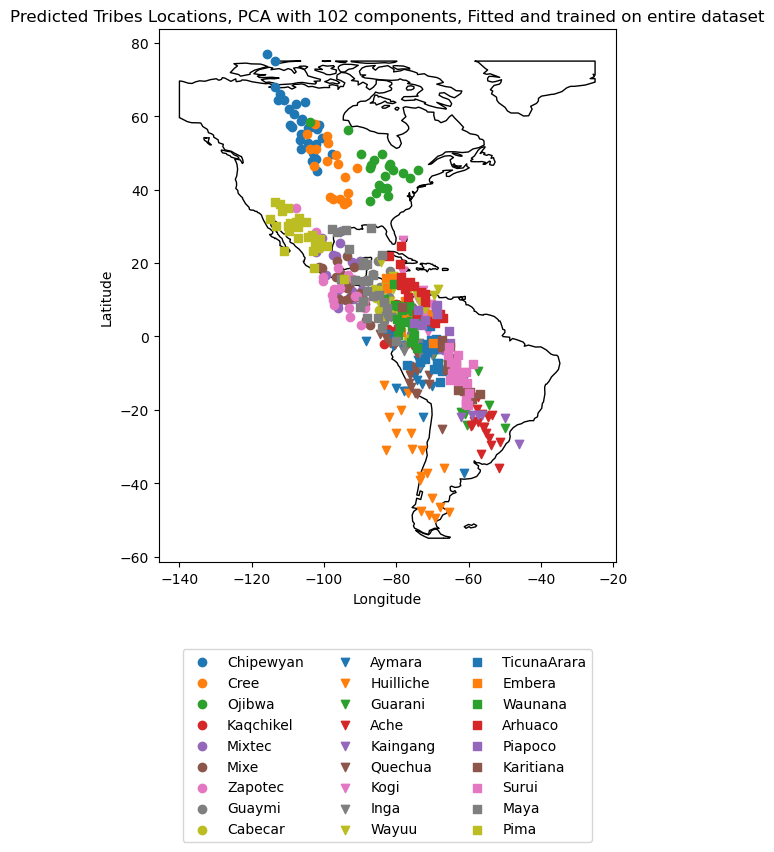

Prediction error:  2108.016288426753


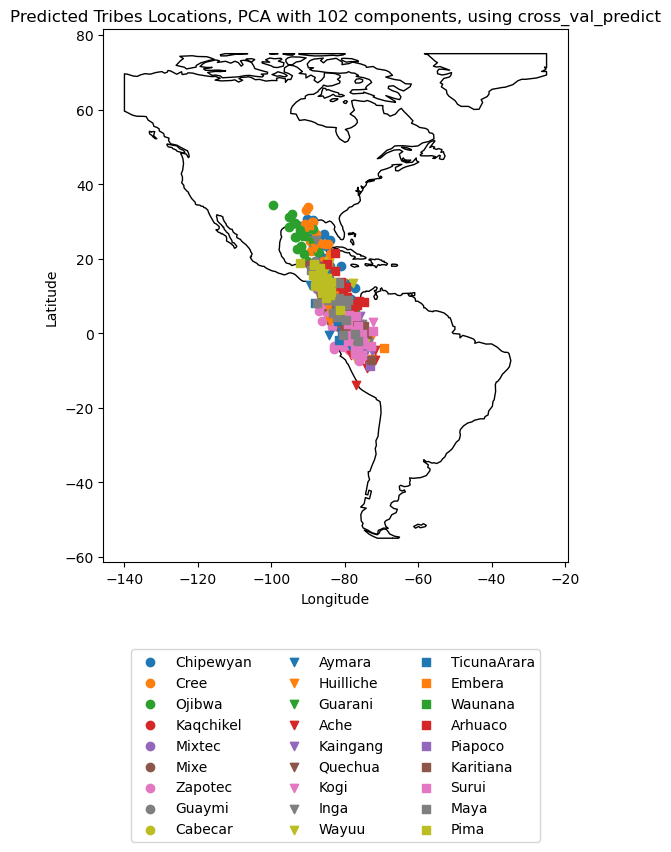

/var/folders/gv/jtdbv_2n0sl_9c1c0kbw4rp80000gn/T/ipykernel_71192/2747188319.py:99: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


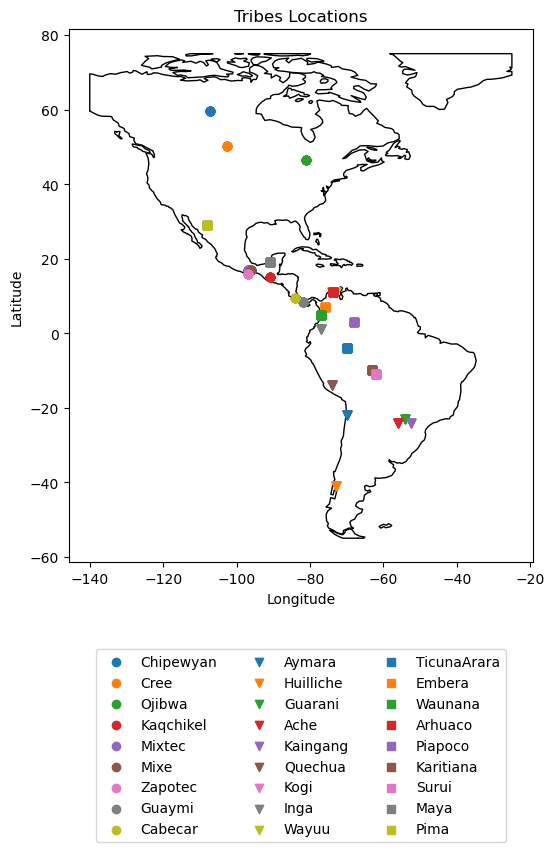

In [27]:
from sklearn.model_selection import cross_val_predict

print('Number of components: ', num_c[10])
print('Mean cv train error: ', train_scores[10])
print('Mean cv test error: ', test_scores[10])


pipe = make_pipeline(
        StandardScaler(),
        PCA(n_components=102),
        LinearRegression()
    )
pipe.fit(X, y)
pred_coords = pipe.predict(X)

print('Prediction error: ', mean_dist_error(pred_coords, y))

world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black') #bounds the map [min long, min lat, max long, max lat]
marker_list = ['o', 'v', 's'] #list of three types of markers
colors_list = [f'C{i}' for i in range(9)] #create a list of 9 colors
for i, tribe in enumerate(gdf['Pop'].unique()): #loop over the unique tribe names
    mask = df['Pop'] == tribe #boolean mask for the current tribe
    curr_coords = pred_coords[mask]
    ax.scatter(curr_coords[:, 1], curr_coords[:, 0], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe) # plots a marker for the tribe with marker type and color decided by the order of which we loop over the tribes, adds tribe label
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3
)
ax.set_title('Predicted Tribes Locations, PCA with 102 components, Fitted and trained on entire dataset')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()


pipe = make_pipeline(
        StandardScaler(),
        PCA(n_components=102),
        LinearRegression()
    )
cv = GroupKFold(n_splits=10)
pred_coords = cross_val_predict(pipe, X, y, cv=cv, groups=tribes)


print('Prediction error: ', mean_dist_error(pred_coords, y))

world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black') #bounds the map [min long, min lat, max long, max lat]
marker_list = ['o', 'v', 's'] #list of three types of markers
colors_list = [f'C{i}' for i in range(9)] #create a list of 9 colors
for i, tribe in enumerate(gdf['Pop'].unique()): #loop over the unique tribe names
    mask = df['Pop'] == tribe #boolean mask for the current tribe
    curr_coords = pred_coords[mask]
    ax.scatter(curr_coords[:, 1], curr_coords[:, 0], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe) # plots a marker for the tribe with marker type and color decided by the order of which we loop over the tribes, adds tribe label
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3
)
ax.set_title('Predicted Tribes Locations, PCA with 102 components, using cross_val_predict')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()


# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude)) #creates a geo df from our original df

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black') #bounds the map [min long, min lat, max long, max lat]
marker_list = ['o', 'v', 's'] #list of three types of markers
colors_list = [f'C{i}' for i in range(9)] #create a list of 9 colors
for i, tribe in enumerate(gdf['Pop'].unique()): #loop over the unique tribe names
    members_tribe = gdf[gdf['Pop'] == tribe] #df filtered on the current tribe
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe) # plots a marker for the tribe with marker type and color decided by the order of which we loop over the tribes, adds tribe label
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3
)
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.


### Answer
The conclusion of our study is that tuning parameters using cross validation and avoiding data leakage when the samples are not IID but belong to diffrent subgroups is paramount for yieling a good result. However, predicting locations of tribes using genetic markers does not seem like a very great idea as the model does not seem to be able to preform very well even for a large number of components when trying to predict the location for a member of a yet unseen tribe. (See predictions using cross_val_predict).
